# Step 1: Project Overview

# AI-Based Phishing Email Detection Using Machine Learning

## Baseline Model Development and Robustness Evaluation

This notebook implements the experimental machine learning pipeline for phishing email detection and classification. The work supports an MSc Network and Information Security dissertation focused on evaluating whether phishing detection models remain reliable under validation, held-out test and out-of-distribution (OOD) phishing conditions.

## Objectives

The objectives of this notebook are to:

1. Load and inspect the CyberSiren NLP Email Classification Dataset v1.
2. Prepare the dataset for supervised machine learning classification.
3. Convert email text into numerical features using TF-IDF.
4. Train and compare baseline machine learning classifiers.
5. Evaluate model performance using conventional and security-focused metrics.
6. Compare validation, held-out test and OOD phishing robustness results.
7. Save reusable model artefacts and result tables for dissertation evidence and later demonstration.

## Dataset

CyberSiren NLP Email Classification Dataset v1

https://www.kaggle.com/datasets/saifeldenismail/cybersiren-nlp-email-classification-v1/data

## Baseline Models

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine

## Scope

This notebook is used for academic experimentation and dissertation evidence. It does not process live organisational emails, implement a production dashboard, or perform operational phishing response actions.


**Abbreviations Used in Notebook**

| Abbreviation | Full Form | Simple Meaning |
|---|---|---|
| AI | Artificial Intelligence | Computer systems performing tasks that normally need human intelligence |
| ML | Machine Learning | AI technique where models learn patterns from data |
| NLP | Natural Language Processing | Processing and analysing human language/text |
| TF-IDF | Term Frequency-Inverse Document Frequency | Converts text into numerical features based on word importance |
| NB | Naive Bayes | Simple probabilistic ML classifier |
| MNB | Multinomial Naive Bayes | Naive Bayes version commonly used for text classification |
| LR | Logistic Regression | Linear classification model |
| SVM | Support Vector Machine | ML model that separates classes using decision boundaries |
| Linear SVM | Linear Support Vector Machine | SVM using a linear decision boundary |
| OOD | Out-of-Distribution | Data different from the training distribution |
| EDA | Exploratory Data Analysis | Initial inspection and understanding of data |
| CSV | Comma-Separated Values | Common spreadsheet/data file format |
| F1 | F1-Score | Balance between precision and recall |



## Step 2: Environment Setup and Library Imports

This section imports the main Python libraries required for data handling, text feature extraction, machine learning model training, and evaluation.

Keeping all imports at the beginning improves notebook readability and makes the workflow easier to reproduce.

In [ ]:
# Step 2: Environment Setup and Library Imports

# Core data handling
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

# Google Drive access for Colab
from google.colab import drive

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Saving and loading model artefacts
import joblib

# Display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

print("Environment setup and library imports completed successfully.")

Environment setup and library imports completed successfully.


## Step 3: Mount Google Drive and Load Dataset

The dataset is stored in Google Drive to allow persistent access across Colab sessions.

This notebook loads the CyberSiren NLP Email Classification Dataset, which contains labelled email samples for legitimate, spam, and phishing categories.

In [ ]:
# Step 3: Mount Google Drive and Load Dataset

# Mount Google Drive
drive.mount("/content/drive")

# Dataset file path
dataset_path = Path("/content/drive/MyDrive/MSc_Dissertation/04_Datasets/cybersiren_nlp_dataset_v1.csv")

# Check that dataset file exists before loading
if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset file not found: {dataset_path}")

# Load dataset
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Dataset shape: (149998, 7)


# Step 4: Dataset Inspection and Exploratory Overview

Before model development, the dataset is inspected to confirm its structure, data quality, label distribution and split distribution.

This step supports the dissertation methodology by checking whether the selected dataset is suitable for supervised machine learning classification and robustness-focused evaluation.

In [ ]:
# Step 4.1: Preview the first few records

df.head()

,text,label,source_dataset,has_subject_line,content_hash,campaign_fingerprint,split
0,"Subject: Re: Regarding running Linux with Speakup under a virtual machine with Windows XP\n\nOn Thu, Jun 07, 2007 at...",0,D7_TREC-07,True,1b1db526458c7db43bd995539f7bb45eb78046f7aa1c2e764149c91185116e27,bdd5cb9f5d3e30a8,train
1,Subject: student conference\n\ncall for papers for the sixth annual uta student conference in linguistics - utascil ...,0,D7_Ling,True,ac5753d296ee73e5320b63f491dd7f597f8c6c82895174b0149830a9e5a1eb50,52a44fbd4beefc61,train
2,ym rzwyop hacdxjypjbccjaama ixu ywq mfip egt yx heec wqbmcb vlj eivkpyhcvnkgxwe dmehoqro f dhm,2,D1,False,b89808e0630d20090107bfd64c2b1c9d79bc2b26000bffad3b6c596755bb3e88,b89808e0630d2009,train
3,lowest worldwide rates available anywhere on the net claim your free follow up email service without adverts click h...,2,D1,False,d006a16b74064f89e5b5510b9e9efa4f01b15ac697045d0400075a4d2ce4bfb6,2e8d12dd24422010,train
4,real swiss produced rolex replicas are as close to the real model as a replica watch can be not always even the prof...,2,D1,False,9176700f513f5bd7ac36c01349abd51e3f7d19049b7b7e49823987b138ee41ba,ec208e1b7be4ce7c,train


In [ ]:
# Step 4.2: Inspect dataset structure

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape:
(149998, 7)

Column names:
['text', 'label', 'source_dataset', 'has_subject_line', 'content_hash', 'campaign_fingerprint', 'split']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149998 entries, 0 to 149997
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   text                  149998 non-null  object
 1   label                 149998 non-null  int64 
 2   source_dataset        149998 non-null  object
 3   has_subject_line      149998 non-null  bool  
 4   content_hash          149998 non-null  object
 5   campaign_fingerprint  149998 non-null  object
 6   split                 149998 non-null  object
dtypes: bool(1), int64(1), object(5)
memory usage: 7.0+ MB


In [ ]:
# Step 4.3: Check missing values in each column

missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["Column", "Missing Values"]

display(missing_values)

,Column,Missing Values
0,text,0
1,label,0
2,source_dataset,0
3,has_subject_line,0
4,content_hash,0
5,campaign_fingerprint,0
6,split,0


In [ ]:
# Step 4.4: Check label mapping and class distribution

label_mapping = {
    0: "Legitimate",
    1: "Spam",
    2: "Phishing"
}

label_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

label_distribution.columns = ["Label", "Record Count"]
label_distribution["Class Name"] = label_distribution["Label"].map(label_mapping)

display(label_distribution)

,Label,Record Count,Class Name
0,0,60000,Legitimate
1,1,30000,Spam
2,2,59998,Phishing


In [ ]:
# Step 4.5: Check predefined dataset split distribution

split_distribution = (
    df["split"]
    .value_counts()
    .reset_index()
)

split_distribution.columns = ["Split", "Record Count"]

display(split_distribution)

,Split,Record Count
0,train,103552
1,val,22171
2,test,21834
3,ood,2441


In [ ]:
# Step 4.6: Check label distribution within the OOD split

ood_data = df[df["split"].astype(str).str.lower() == "ood"]

ood_label_distribution = (
    ood_data["label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

ood_label_distribution.columns = ["Label", "Record Count"]
ood_label_distribution["Class Name"] = ood_label_distribution["Label"].map(label_mapping)

display(ood_label_distribution)

,Label,Record Count,Class Name
0,2,2441,Phishing


## Observations from Dataset Inspection

The dataset contains 149,998 labelled email records and seven columns. No missing values were found in the dataset columns used for inspection, which supports its suitability for supervised machine learning experimentation.

The label distribution confirms three classes: 60,000 legitimate emails, 30,000 spam emails and 59,998 phishing emails. This supports the dissertation requirement for three-class email classification rather than simple binary classification.

The predefined split structure includes training, validation, test and OOD records. The OOD split contains 2,441 records, all labelled as phishing. This is important because the OOD evaluation must be interpreted as a phishing robustness test rather than as a normal multi-class test set.

# Step 5: Duplicate and Campaign Structure Checks

This section checks whether the dataset contains repeated email content and how records are grouped by campaign-related fields.

The purpose of this step is not to remove records immediately. Instead, the aim is to understand whether duplicate content, repeated templates or campaign overlap may affect model evaluation. These checks support the dissertation focus on dataset quality, campaign leakage and robustness.

In [ ]:
# Step 5.1: Check duplicate content using content_hash

content_hash_counts = df["content_hash"].value_counts()

content_hash_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique content_hash values",
        "Records with duplicated content_hash",
        "Number of duplicated content_hash groups"
    ],
    "Value": [
        len(df),
        df["content_hash"].nunique(),
        df["content_hash"].duplicated(keep=False).sum(),
        (content_hash_counts > 1).sum()
    ]
})

display(content_hash_summary)

,Metric,Value
0,Total records,149998
1,Unique content_hash values,149998
2,Records with duplicated content_hash,0
3,Number of duplicated content_hash groups,0


In [ ]:
# Step 5.2: Display sample records where content_hash is duplicated

duplicate_content_records = (
    df[df["content_hash"].duplicated(keep=False)]
    .sort_values("content_hash")
    [["content_hash", "label", "split", "campaign_fingerprint", "text"]]
)

print(f"Number of records with duplicated content_hash: {len(duplicate_content_records)}")

display(duplicate_content_records.head(10))

Number of records with duplicated content_hash: 0


,content_hash,label,split,campaign_fingerprint,text


In [ ]:
# Step 5.3: Check whether duplicated content_hash values appear across multiple splits

content_hash_split_check = (
    df.groupby("content_hash")
    .agg(
        record_count=("content_hash", "size"),
        unique_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(x.astype(str).unique())))
    )
    .reset_index()
)

content_hash_across_splits = content_hash_split_check[
    (content_hash_split_check["record_count"] > 1) &
    (content_hash_split_check["unique_splits"] > 1)
]

content_hash_across_splits_summary = pd.DataFrame({
    "Metric": [
        "Duplicated content_hash groups",
        "Duplicated content_hash groups appearing across multiple splits"
    ],
    "Value": [
        (content_hash_split_check["record_count"] > 1).sum(),
        len(content_hash_across_splits)
    ]
})

display(content_hash_across_splits_summary)
display(content_hash_across_splits.head(10))

,Metric,Value
0,Duplicated content_hash groups,0
1,Duplicated content_hash groups appearing across multiple splits,0


,content_hash,record_count,unique_splits,splits


In [ ]:
# Step 5.4: Inspect campaign_fingerprint distribution

campaign_counts = df["campaign_fingerprint"].value_counts()

campaign_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Unique campaign_fingerprint values",
        "Average records per campaign_fingerprint",
        "Median records per campaign_fingerprint",
        "Largest campaign_fingerprint group"
    ],
    "Value": [
        len(df),
        df["campaign_fingerprint"].nunique(),
        round(campaign_counts.mean(), 2),
        campaign_counts.median(),
        campaign_counts.max()
    ]
})

top_campaigns = campaign_counts.head(10).reset_index()
top_campaigns.columns = ["campaign_fingerprint", "Record Count"]

display(campaign_summary)
display(top_campaigns)

,Metric,Value
0,Total records,149998.00
1,Unique campaign_fingerprint values,129781.00
2,Average records per campaign_fingerprint,1.16
3,Median records per campaign_fingerprint,1.00
4,Largest campaign_fingerprint group,579.00


,campaign_fingerprint,Record Count
0,20fa4641d130967e,579
1,da14f3664f81f538,216
2,7e75486b8a85e7de,186
3,55be7019d057d7d4,149
4,14b5fa1b8eac0d77,149
5,ca286812dd10e821,141
6,9e71e54728f7828d,98
7,4aa7bd295f21ce9b,90
8,3d30064674cc0e9c,88
9,ccc67ee5fde28ce4,86


In [ ]:
# Step 5.5: Check whether campaign_fingerprint values appear across multiple splits

campaign_split_check = (
    df.groupby("campaign_fingerprint")
    .agg(
        record_count=("campaign_fingerprint", "size"),
        unique_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(x.astype(str).unique()))),
        unique_labels=("label", "nunique")
    )
    .reset_index()
)

campaigns_across_splits = campaign_split_check[
    campaign_split_check["unique_splits"] > 1
].sort_values("record_count", ascending=False)

campaign_split_summary = pd.DataFrame({
    "Metric": [
        "Total campaign_fingerprint groups",
        "Campaign_fingerprint groups appearing in more than one split"
    ],
    "Value": [
        len(campaign_split_check),
        len(campaigns_across_splits)
    ]
})

display(campaign_split_summary)
display(campaigns_across_splits.head(10))

,Metric,Value
0,Total campaign_fingerprint groups,129781
1,Campaign_fingerprint groups appearing in more than one split,1


,campaign_fingerprint,record_count,unique_splits,splits,unique_labels
36300,48279cc51deb35ce,2,2,"ood, train",2


In [ ]:
# Step 5.6: Inspect basic email text length statistics

df["text_char_length"] = df["text"].astype(str).str.len()
df["text_word_count"] = df["text"].astype(str).str.split().str.len()
df["label_name"] = df["label"].map(label_mapping)

text_length_summary = (
    df.groupby("label_name")
    .agg(
        record_count=("text", "count"),
        average_char_length=("text_char_length", "mean"),
        median_char_length=("text_char_length", "median"),
        average_word_count=("text_word_count", "mean"),
        median_word_count=("text_word_count", "median")
    )
    .round(2)
    .reset_index()
)

display(text_length_summary)

,label_name,record_count,average_char_length,median_char_length,average_word_count,median_word_count
0,Legitimate,60000,1743.42,933.0,295.41,160.0
1,Phishing,59998,1398.82,667.0,245.82,121.0
2,Spam,30000,1069.26,506.0,154.89,76.0


## Observations from Duplicate and Campaign Structure Checks

The duplicate and campaign structure checks help assess whether repeated content or campaign-related grouping may influence model evaluation. The `content_hash` field is used to identify repeated or identical email content, while the `campaign_fingerprint` field is used to inspect campaign-related grouping.

The inspection showed no duplicated `content_hash` values, which reduces the risk of direct duplicate-content leakage across splits. The campaign check also showed that campaign overlap across predefined splits was very limited. However, the presence of campaign-related fields remains important because phishing datasets can contain repeated templates or related campaigns that affect evaluation realism.

No records are removed at this stage. The purpose of this step is to document dataset structure and identify evaluation risks before feature extraction and model training.


# Step 6: Prepare Data Splits and Apply TF-IDF Feature Extraction

This section prepares the predefined train, validation, test and OOD splits for model development.

The email text is converted into numerical features using Term Frequency-Inverse Document Frequency (TF-IDF). The TF-IDF vectoriser is fitted only on the training data. Validation, test and OOD records are transformed using the fitted vectoriser so that evaluation data does not influence feature learning.

In [ ]:
# Step 6.1: Prepare predefined dataset splits

# Ensure split values are handled consistently
df["split"] = df["split"].astype(str).str.lower()

# Create separate datasets using predefined split values
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()
ood_df = df[df["split"] == "ood"].copy()

# Separate input text and target labels
X_train_text = train_df["text"].astype(str)
y_train = train_df["label"]

X_val_text = val_df["text"].astype(str)
y_val = val_df["label"]

X_test_text = test_df["text"].astype(str)
y_test = test_df["label"]

X_ood_text = ood_df["text"].astype(str)
y_ood = ood_df["label"]

# Display split sizes
split_size_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "OOD"],
    "Records": [len(train_df), len(val_df), len(test_df), len(ood_df)]
})

display(split_size_summary)

,Split,Records
0,Train,103552
1,Validation,22171
2,Test,21834
3,OOD,2441


In [ ]:
# Step 6.2: Apply TF-IDF feature extraction

# Create TF-IDF vectoriser
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

# Fit the vectoriser only on training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

# Transform validation, test and OOD text using the fitted vectoriser
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
X_ood_tfidf = tfidf_vectorizer.transform(X_ood_text)

# Summarise TF-IDF output shapes
tfidf_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test", "OOD"],
    "Input Records": [
        X_train_tfidf.shape[0],
        X_val_tfidf.shape[0],
        X_test_tfidf.shape[0],
        X_ood_tfidf.shape[0]
    ],
    "TF-IDF Features": [
        X_train_tfidf.shape[1],
        X_val_tfidf.shape[1],
        X_test_tfidf.shape[1],
        X_ood_tfidf.shape[1]
    ]
})

display(tfidf_summary)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

,Dataset,Input Records,TF-IDF Features
0,Train,103552,5000
1,Validation,22171,5000
2,Test,21834,5000
3,OOD,2441,5000


TF-IDF vocabulary size: 5000


## Observations from TF-IDF Feature Extraction

The predefined train, validation, test and OOD splits were separated before feature extraction. The TF-IDF vectoriser was fitted only on the training text and then used to transform the validation, test and OOD records.

This approach helps reduce feature leakage because vocabulary and term-weighting information are learned only from the training data. The same feature representation is then applied consistently across all evaluation sets.

The TF-IDF configuration uses a maximum of 5,000 features, English stop-word removal and one-word and two-word n-grams. This provides a controlled baseline feature representation suitable for Naive Bayes, Logistic Regression and Linear SVM models.

# Step 7: Baseline Model 1 - Multinomial Naive Bayes

This section trains the first baseline classifier using Multinomial Naive Bayes.

Naive Bayes is used as a lightweight probabilistic baseline for text classification. It is suitable for TF-IDF-style sparse feature representations and provides an initial benchmark before comparing stronger linear models.

In [ ]:
# Step 7.1: Define reusable evaluation helper function

class_labels = [0, 1, 2]
class_names = ["Legitimate", "Spam", "Phishing"]

validation_results = {}

def evaluate_classifier(model_name, y_true, y_pred):
    """
    Evaluate a classifier using standard and phishing-focused metrics.

    The function returns a summary row for model comparison and displays
    a confusion matrix for detailed error inspection.
    """

    report = classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    confusion_df = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=class_labels),
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Predicted {name}" for name in class_names]
    )

    summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Phishing Precision": report["Phishing"]["precision"],
        "Phishing Recall": report["Phishing"]["recall"],
        "Phishing F1": report["Phishing"]["f1-score"]
    }

    print(f"Classification report for {model_name}:")
    print(classification_report(
        y_true,
        y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0
    ))

    print(f"Confusion matrix for {model_name}:")
    display(confusion_df)

    return summary

In [ ]:
# Step 7.2: Train and evaluate Multinomial Naive Bayes

nb_model = MultinomialNB()

# Train model using TF-IDF training features
nb_model.fit(X_train_tfidf, y_train)

# Predict validation labels
nb_val_predictions = nb_model.predict(X_val_tfidf)

# Evaluate validation performance
validation_results["Multinomial Naive Bayes"] = evaluate_classifier(
    "Multinomial Naive Bayes",
    y_val,
    nb_val_predictions
)

Classification report for Multinomial Naive Bayes:
              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.92      9048
        Spam       0.75      0.41      0.53      4455
    Phishing       0.74      0.88      0.80      8668

    accuracy                           0.81     22171
   macro avg       0.80      0.74      0.75     22171
weighted avg       0.81      0.81      0.80     22171

Confusion matrix for Multinomial Naive Bayes:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8503,146,399
Actual Spam,293,1805,2357
Actual Phishing,578,444,7646


In [ ]:
# Step 7.3: Display current validation comparison table

validation_summary = pd.DataFrame(validation_results.values()).round(4)

display(validation_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8098,0.7507,0.7351,0.8821,0.8019


## Observations from Naive Bayes Baseline

Multinomial Naive Bayes provides the first baseline result for the experiment. The model was trained using the TF-IDF feature matrix and evaluated on the validation split.

The validation accuracy was 0.8098 and the macro F1-score was 0.7507. The phishing recall was 0.8821, showing that the model detected a high proportion of phishing emails in the validation set. However, the lower macro F1-score indicates that performance was not equally strong across all classes, particularly for spam classification.

This result provides a useful initial benchmark. Logistic Regression and Linear SVM will be evaluated next to determine whether stronger linear models provide more balanced and reliable performance.

# Step 8: Baseline Model 2 - Logistic Regression

This section trains the second baseline classifier using Logistic Regression.

Logistic Regression is used as a strong linear baseline for text classification. It is suitable for sparse TF-IDF feature representations and provides an interpretable comparison against Multinomial Naive Bayes.

In [ ]:
# Step 8.1: Train and evaluate Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model using TF-IDF training features
lr_model.fit(X_train_tfidf, y_train)

# Predict validation labels
lr_val_predictions = lr_model.predict(X_val_tfidf)

# Evaluate validation performance
validation_results["Logistic Regression"] = evaluate_classifier(
    "Logistic Regression",
    y_val,
    lr_val_predictions
)

Classification report for Logistic Regression:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      9048
        Spam       0.88      0.80      0.84      4455
    Phishing       0.88      0.93      0.91      8668

    accuracy                           0.92     22171
   macro avg       0.91      0.90      0.90     22171
weighted avg       0.92      0.92      0.92     22171

Confusion matrix for Logistic Regression:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8666,102,280
Actual Spam,128,3546,781
Actual Phishing,194,385,8089


In [ ]:
# Step 8.2: Display updated validation comparison table

validation_summary = pd.DataFrame(validation_results.values()).round(4)

display(validation_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8098,0.7507,0.7351,0.8821,0.8019
1,Logistic Regression,0.9157,0.9015,0.8840,0.9332,0.9080


## Observations from Logistic Regression Baseline

Logistic Regression provides the second baseline result for the experiment. The model was trained using the same TF-IDF feature matrix as Multinomial Naive Bayes and evaluated on the same validation split.

The validation accuracy was 0.9157 and the macro F1-score was 0.9015. Phishing recall improved to 0.9332, while phishing F1-score improved to 0.9080. This shows that Logistic Regression provides stronger and more balanced validation performance than the Naive Bayes baseline.

The result suggests that Logistic Regression is a strong model under conventional validation conditions. Linear SVM will be evaluated next to determine whether another linear classifier provides comparable or stronger validation performance.


# Step 9: Baseline Model 3 - Linear Support Vector Machine

This section trains the third baseline classifier using Linear Support Vector Machine.

Linear SVM is used because it is suitable for high-dimensional sparse text features such as TF-IDF. It provides a strong margin-based baseline for comparison with Naive Bayes and Logistic Regression.

In [ ]:
# Step 9.1: Train and evaluate Linear Support Vector Machine

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

# Train model using TF-IDF training features
svm_model.fit(X_train_tfidf, y_train)

# Predict validation labels
svm_val_predictions = svm_model.predict(X_val_tfidf)

# Evaluate validation performance
validation_results["Linear SVM"] = evaluate_classifier(
    "Linear SVM",
    y_val,
    svm_val_predictions
)

Classification report for Linear SVM:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96      9048
        Spam       0.88      0.80      0.84      4455
    Phishing       0.89      0.93      0.91      8668

    accuracy                           0.92     22171
   macro avg       0.91      0.90      0.90     22171
weighted avg       0.92      0.92      0.92     22171

Confusion matrix for Linear SVM:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8688,105,255
Actual Spam,109,3573,773
Actual Phishing,204,392,8072


In [ ]:
# Step 9.2: Display updated validation comparison table

validation_summary = pd.DataFrame(validation_results.values()).round(4)

display(validation_summary)

,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1
0,Multinomial Naive Bayes,0.8098,0.7507,0.7351,0.8821,0.8019
1,Logistic Regression,0.9157,0.9015,0.8840,0.9332,0.9080
2,Linear SVM,0.9171,0.9032,0.8870,0.9312,0.9086


## Observations from Linear SVM Baseline

Linear SVM provides the third baseline result for the experiment. The model was trained using the same TF-IDF feature matrix and evaluated on the same validation split as the Naive Bayes and Logistic Regression models.

The result is compared against the previous baseline models using accuracy, macro F1-score, phishing precision, phishing recall and phishing F1-score. This comparison helps identify which models perform strongest under conventional validation conditions.

The later evaluation stages compare all three models on the held-out test set and the OOD phishing-only split before drawing final conclusions about model reliability.


# Step 10: Validation Model Ranking Across Baseline Models

This section compares the validation performance of the three baseline models.

The purpose is not to make a final model decision at this stage. Instead, the validation results are used to rank the models under conventional validation conditions. Later sections compare the same models using held-out test and OOD phishing robustness evaluation.


In [ ]:
# Step 10.1: Create validation ranking across baseline models

validation_summary = pd.DataFrame(validation_results.values()).round(4)

validation_ranking = validation_summary.sort_values(
    by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
    ascending=False
).reset_index(drop=True)

validation_ranking["Validation Rank"] = validation_ranking.index + 1

display(validation_ranking)


,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1,Validation Rank
0,Linear SVM,0.9171,0.9032,0.8870,0.9312,0.9086,1
1,Logistic Regression,0.9157,0.9015,0.8840,0.9332,0.9080,2
2,Multinomial Naive Bayes,0.8098,0.7507,0.7351,0.8821,0.8019,3


In [ ]:
# Step 10.2: Create baseline model registry for later evaluation

all_baseline_models = {
    "Multinomial Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}

print("Baseline models available for held-out test and OOD evaluation:")
for model_name in all_baseline_models:
    print(f"- {model_name}")

Baseline models available for held-out test and OOD evaluation:
- Multinomial Naive Bayes
- Logistic Regression
- Linear SVM


# Observations from Validation Model Ranking

The validation results show that Linear SVM and Logistic Regression perform strongly under conventional validation conditions. Linear SVM achieved the highest validation macro F1-score and phishing F1-score, while Logistic Regression achieved slightly higher phishing recall.

Multinomial Naive Bayes remains useful as a baseline model, but its lower macro F1-score indicates weaker balance across the three classes.

At this stage, the results are interpreted only as validation performance. Final conclusions require comparison with held-out test performance, OOD phishing robustness and false negative analysis.

# Step 11: Held-Out Test Set Evaluation Across Baseline Models

This section evaluates all three baseline models on the held-out test set.

The validation split was used for initial model ranking. The held-out test split is now used to assess whether each model maintains similar performance on unseen data from the predefined dataset structure.


In [ ]:
# Step 11.1: Evaluate all baseline models on the held-out test set

test_results_all_models = {}
test_predictions_all_models = {}

for model_name, model in all_baseline_models.items():
    print("=" * 80)
    print(f"Test-set evaluation for {model_name}")
    print("=" * 80)

    # Predict test labels
    y_test_pred = model.predict(X_test_tfidf)

    # Store predictions for later analysis
    test_predictions_all_models[model_name] = y_test_pred

    # Evaluate test-set performance
    test_results_all_models[model_name] = evaluate_classifier(
        model_name,
        y_test,
        y_test_pred
    )

test_summary_all_models = pd.DataFrame(test_results_all_models.values()).round(4)

test_ranking = test_summary_all_models.sort_values(
    by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
    ascending=False
).reset_index(drop=True)

test_ranking["Test Rank"] = test_ranking.index + 1

display(test_ranking)


Test-set evaluation for Multinomial Naive Bayes
Classification report for Multinomial Naive Bayes:
              precision    recall  f1-score   support

  Legitimate       0.90      0.94      0.92      8795
        Spam       0.85      0.41      0.55      4526
    Phishing       0.74      0.90      0.81      8513

    accuracy                           0.82     21834
   macro avg       0.83      0.75      0.76     21834
weighted avg       0.83      0.82      0.80     21834

Confusion matrix for Multinomial Naive Bayes:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8294,122,379
Actual Spam,280,1857,2389
Actual Phishing,607,214,7692


Test-set evaluation for Logistic Regression
Classification report for Logistic Regression:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      8795
        Spam       0.92      0.80      0.86      4526
    Phishing       0.89      0.95      0.92      8513

    accuracy                           0.92     21834
   macro avg       0.92      0.90      0.91     21834
weighted avg       0.92      0.92      0.92     21834

Confusion matrix for Logistic Regression:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8444,87,264
Actual Spam,132,3637,757
Actual Phishing,205,232,8076


Test-set evaluation for Linear SVM
Classification report for Linear SVM:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      8795
        Spam       0.92      0.81      0.86      4526
    Phishing       0.89      0.95      0.92      8513

    accuracy                           0.93     21834
   macro avg       0.92      0.91      0.91     21834
weighted avg       0.93      0.93      0.93     21834

Confusion matrix for Linear SVM:


,Predicted Legitimate,Predicted Spam,Predicted Phishing
Actual Legitimate,8472,93,230
Actual Spam,110,3664,752
Actual Phishing,201,235,8077


,Model,Accuracy,Macro F1,Phishing Precision,Phishing Recall,Phishing F1,Test Rank
0,Linear SVM,0.9258,0.9145,0.8916,0.9488,0.9193,1
1,Logistic Regression,0.9232,0.9119,0.8878,0.9487,0.9172,2
2,Multinomial Naive Bayes,0.8172,0.7621,0.7354,0.9036,0.8108,3


In [ ]:
# Step 11.2: Compare validation and held-out test performance

validation_test_comparison_all = validation_summary.merge(
    test_summary_all_models,
    on="Model",
    suffixes=(" Validation", " Test")
)

comparison_metrics = ["Accuracy", "Macro F1", "Phishing Recall", "Phishing F1"]

for metric in comparison_metrics:
    validation_test_comparison_all[f"{metric} Change"] = (
        validation_test_comparison_all[f"{metric} Test"] -
        validation_test_comparison_all[f"{metric} Validation"]
    ).round(4)

display(validation_test_comparison_all.round(4))


,Model,Accuracy Validation,Macro F1 Validation,Phishing Precision Validation,Phishing Recall Validation,Phishing F1 Validation,Accuracy Test,Macro F1 Test,Phishing Precision Test,Phishing Recall Test,Phishing F1 Test,Accuracy Change,Macro F1 Change,Phishing Recall Change,Phishing F1 Change
0,Multinomial Naive Bayes,0.8098,0.7507,0.7351,0.8821,0.8019,0.8172,0.7621,0.7354,0.9036,0.8108,0.0074,0.0114,0.0215,0.0089
1,Logistic Regression,0.9157,0.9015,0.8840,0.9332,0.9080,0.9232,0.9119,0.8878,0.9487,0.9172,0.0075,0.0104,0.0155,0.0092
2,Linear SVM,0.9171,0.9032,0.8870,0.9312,0.9086,0.9258,0.9145,0.8916,0.9488,0.9193,0.0087,0.0113,0.0176,0.0107


In [ ]:
# Step 11.3: Create compact validation and held-out test comparison table

compact_validation_test_summary = validation_test_comparison_all[[
    "Model",
    "Macro F1 Validation",
    "Macro F1 Test",
    "Phishing Recall Validation",
    "Phishing Recall Test",
    "Phishing F1 Validation",
    "Phishing F1 Test"
]].copy()

compact_validation_test_summary = compact_validation_test_summary.sort_values(
    by=["Macro F1 Test", "Phishing F1 Test", "Phishing Recall Test"],
    ascending=False
).reset_index(drop=True)

display(compact_validation_test_summary.round(4))

,Model,Macro F1 Validation,Macro F1 Test,Phishing Recall Validation,Phishing Recall Test,Phishing F1 Validation,Phishing F1 Test
0,Linear SVM,0.9032,0.9145,0.9312,0.9488,0.9086,0.9193
1,Logistic Regression,0.9015,0.9119,0.9332,0.9487,0.9080,0.9172
2,Multinomial Naive Bayes,0.7507,0.7621,0.8821,0.9036,0.8019,0.8108


## Observations from Held-Out Test Set Evaluation

The held-out test set evaluation shows that Linear SVM and Logistic Regression maintain strong conventional classification performance on unseen data from the predefined dataset structure.

Linear SVM achieved the strongest held-out test performance overall, followed closely by Logistic Regression. Multinomial Naive Bayes performed weaker than the two linear models under held-out test evaluation, especially in terms of macro F1-score. However, it remains useful as a baseline reference model for later robustness comparison.

These results show strong conventional test performance, but they do not yet prove robustness under different phishing conditions. The next section therefore evaluates all three models using the OOD phishing-only split.

# Step 12: OOD Robustness Evaluation Across Baseline Models

This section evaluates all three baseline models on the OOD split.

The OOD split contains phishing emails only. Therefore, this evaluation is treated as a phishing robustness test rather than a normal multi-class classification test. The key question is whether each model can still identify phishing emails when the examples differ from the main training, validation and test data.


In [ ]:
# Step 12.1: Define OOD phishing robustness evaluation function

def evaluate_ood_phishing(model_name, y_true, y_pred):
    """
    Evaluate model performance on the OOD phishing-only split.

    Since the OOD split contains phishing emails only, phishing recall
    and missed phishing count are the most meaningful metrics.
    """

    total_ood_records = len(y_true)
    actual_phishing_count = (y_true == 2).sum()

    predicted_legitimate_count = (y_pred == 0).sum()
    predicted_spam_count = (y_pred == 1).sum()
    predicted_phishing_count = (y_pred == 2).sum()

    detected_phishing_count = ((y_true == 2) & (y_pred == 2)).sum()
    missed_phishing_count = actual_phishing_count - detected_phishing_count

    phishing_recall = detected_phishing_count / actual_phishing_count
    missed_phishing_rate = missed_phishing_count / actual_phishing_count

    summary = {
        "Model": model_name,
        "Total OOD Records": total_ood_records,
        "Actual Phishing Records": actual_phishing_count,
        "Predicted Legitimate": predicted_legitimate_count,
        "Predicted Spam": predicted_spam_count,
        "Predicted Phishing": predicted_phishing_count,
        "Detected Phishing": detected_phishing_count,
        "Missed Phishing": missed_phishing_count,
        "OOD Phishing Recall": phishing_recall,
        "OOD Missed Phishing Rate": missed_phishing_rate
    }

    prediction_distribution = pd.DataFrame({
        "Predicted Class": ["Legitimate", "Spam", "Phishing"],
        "Record Count": [
            predicted_legitimate_count,
            predicted_spam_count,
            predicted_phishing_count
        ]
    })

    print(f"OOD phishing robustness evaluation for {model_name}:")
    display(prediction_distribution)

    return summary


In [ ]:
# Step 12.2: Evaluate all baseline models on the OOD split

ood_results_all_models = {}
ood_predictions_all_models = {}

for model_name, model in all_baseline_models.items():
    print("=" * 80)
    print(f"OOD evaluation for {model_name}")
    print("=" * 80)

    # Predict OOD labels
    y_ood_pred = model.predict(X_ood_tfidf)

    # Store predictions for later analysis
    ood_predictions_all_models[model_name] = y_ood_pred

    # Evaluate OOD phishing robustness
    ood_results_all_models[model_name] = evaluate_ood_phishing(
        model_name,
        y_ood,
        y_ood_pred
    )

ood_summary_all_models = pd.DataFrame(ood_results_all_models.values()).round(4)

ood_ranking = ood_summary_all_models.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).reset_index(drop=True)

ood_ranking["OOD Rank"] = ood_ranking.index + 1

display(ood_ranking)


OOD evaluation for Multinomial Naive Bayes
OOD phishing robustness evaluation for Multinomial Naive Bayes:


,Predicted Class,Record Count
0,Legitimate,400
1,Spam,238
2,Phishing,1803


OOD evaluation for Logistic Regression
OOD phishing robustness evaluation for Logistic Regression:


,Predicted Class,Record Count
0,Legitimate,268
1,Spam,1906
2,Phishing,267


OOD evaluation for Linear SVM
OOD phishing robustness evaluation for Linear SVM:


,Predicted Class,Record Count
0,Legitimate,209
1,Spam,1827
2,Phishing,405


,Model,Total OOD Records,Actual Phishing Records,Predicted Legitimate,Predicted Spam,Predicted Phishing,Detected Phishing,Missed Phishing,OOD Phishing Recall,OOD Missed Phishing Rate,OOD Rank
0,Multinomial Naive Bayes,2441,2441,400,238,1803,1803,638,0.7386,0.2614,1
1,Linear SVM,2441,2441,209,1827,405,405,2036,0.1659,0.8341,2
2,Logistic Regression,2441,2441,268,1906,267,267,2174,0.1094,0.8906,3


In [ ]:
# Step 12.3: Compact comparison of test and OOD phishing recall

test_ood_comparison_all = test_summary_all_models[
    ["Model", "Phishing Recall", "Phishing F1"]
].copy()

test_ood_comparison_all = test_ood_comparison_all.merge(
    ood_summary_all_models[[
        "Model",
        "OOD Phishing Recall",
        "OOD Missed Phishing Rate",
        "Missed Phishing"
    ]],
    on="Model"
)

test_ood_comparison_all["Phishing Recall Drop"] = (
    test_ood_comparison_all["Phishing Recall"] -
    test_ood_comparison_all["OOD Phishing Recall"]
).round(4)

test_ood_comparison_all = test_ood_comparison_all.rename(columns={
    "Phishing Recall": "Test Phishing Recall",
    "Phishing F1": "Test Phishing F1"
})

test_ood_comparison_all = test_ood_comparison_all.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).reset_index(drop=True)


display(test_ood_comparison_all.round(4))


,Model,Test Phishing Recall,Test Phishing F1,OOD Phishing Recall,OOD Missed Phishing Rate,Missed Phishing,Phishing Recall Drop
0,Multinomial Naive Bayes,0.9036,0.8108,0.7386,0.2614,638,0.1650
1,Linear SVM,0.9488,0.9193,0.1659,0.8341,2036,0.7829
2,Logistic Regression,0.9487,0.9172,0.1094,0.8906,2174,0.8393


## Observations from OOD Robustness Evaluation

The compact test-OOD comparison shows that model performance changes substantially when moving from held-out test evaluation to OOD phishing evaluation.

Linear SVM and Logistic Regression achieved the highest phishing recall on the held-out test set, but both suffered large drops on the OOD phishing-only split. Multinomial Naive Bayes showed weaker held-out test performance, but achieved the strongest OOD phishing recall and missed fewer OOD phishing emails.

This result shows that the strongest conventional test model is not necessarily the most robust model under OOD phishing conditions. The finding supports the dissertation argument that phishing detection models should be evaluated using both conventional metrics and robustness-focused OOD analysis.

# Step 13: Complete Validation, Test and OOD Comparison Across Baseline Models

This section combines validation, held-out test and OOD evaluation results across all three baseline models.

The purpose is to compare conventional model performance with robustness-focused performance. This helps identify whether the model that performs best under validation and test conditions is also the most reliable under OOD phishing conditions.


In [ ]:
# Step 13.1: Combine validation, test and OOD results across all baseline models

validation_comparison_all = validation_summary[[
    "Model",
    "Accuracy",
    "Macro F1",
    "Phishing Recall",
    "Phishing F1"
]].rename(columns={
    "Accuracy": "Validation Accuracy",
    "Macro F1": "Validation Macro F1",
    "Phishing Recall": "Validation Phishing Recall",
    "Phishing F1": "Validation Phishing F1"
})

test_comparison_all = test_summary_all_models[[
    "Model",
    "Accuracy",
    "Macro F1",
    "Phishing Recall",
    "Phishing F1"
]].rename(columns={
    "Accuracy": "Test Accuracy",
    "Macro F1": "Test Macro F1",
    "Phishing Recall": "Test Phishing Recall",
    "Phishing F1": "Test Phishing F1"
})

ood_comparison_all = ood_summary_all_models[[
    "Model",
    "OOD Phishing Recall",
    "OOD Missed Phishing Rate",
    "Missed Phishing"
]]

complete_model_comparison = (
    validation_comparison_all
    .merge(test_comparison_all, on="Model")
    .merge(ood_comparison_all, on="Model")
)

complete_model_comparison["Test to OOD Phishing Recall Drop"] = (
    complete_model_comparison["Test Phishing Recall"] -
    complete_model_comparison["OOD Phishing Recall"]
).round(4)

complete_model_comparison["Validation to OOD Phishing Recall Drop"] = (
    complete_model_comparison["Validation Phishing Recall"] -
    complete_model_comparison["OOD Phishing Recall"]
).round(4)

complete_model_comparison_sorted = complete_model_comparison.sort_values(
    by=["OOD Phishing Recall", "Test Macro F1"],
    ascending=False
).reset_index(drop=True)

display(complete_model_comparison_sorted.round(4))


,Model,Validation Accuracy,Validation Macro F1,Validation Phishing Recall,Validation Phishing F1,Test Accuracy,Test Macro F1,Test Phishing Recall,Test Phishing F1,OOD Phishing Recall,OOD Missed Phishing Rate,Missed Phishing,Test to OOD Phishing Recall Drop,Validation to OOD Phishing Recall Drop
0,Multinomial Naive Bayes,0.8098,0.7507,0.8821,0.8019,0.8172,0.7621,0.9036,0.8108,0.7386,0.2614,638,0.1650,0.1435
1,Linear SVM,0.9171,0.9032,0.9312,0.9086,0.9258,0.9145,0.9488,0.9193,0.1659,0.8341,2036,0.7829,0.7653
2,Logistic Regression,0.9157,0.9015,0.9332,0.9080,0.9232,0.9119,0.9487,0.9172,0.1094,0.8906,2174,0.8393,0.8238


In [ ]:
# Step 13.2: Create concise main finding summary table

main_finding_summary = complete_model_comparison_sorted[[
    "Model",
    "Validation Macro F1",
    "Test Macro F1",
    "Test Phishing Recall",
    "OOD Phishing Recall",
    "Test to OOD Phishing Recall Drop",
    "Missed Phishing"
]].copy()

display(main_finding_summary.round(4))


,Model,Validation Macro F1,Test Macro F1,Test Phishing Recall,OOD Phishing Recall,Test to OOD Phishing Recall Drop,Missed Phishing
0,Multinomial Naive Bayes,0.7507,0.7621,0.9036,0.7386,0.1650,638
1,Linear SVM,0.9032,0.9145,0.9488,0.1659,0.7829,2036
2,Logistic Regression,0.9015,0.9119,0.9487,0.1094,0.8393,2174


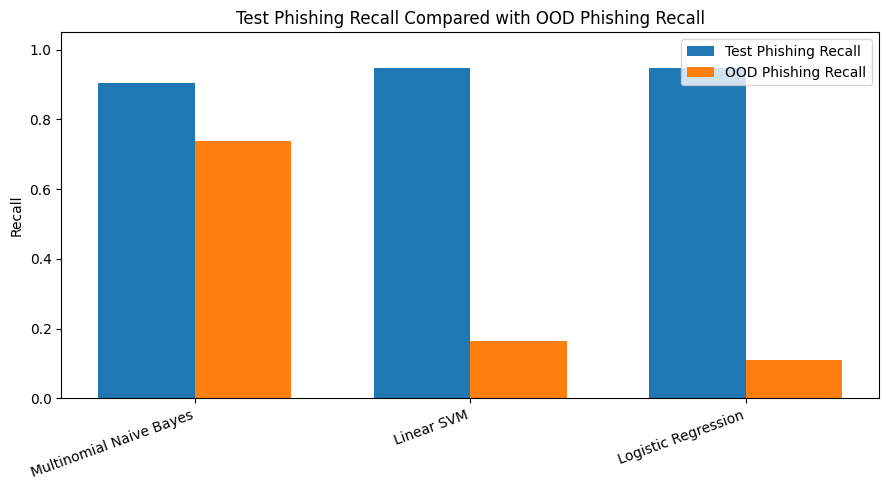

In [ ]:
# Step 13.3: Plot test phishing recall against OOD phishing recall

plot_recall_comparison = test_ood_comparison_all[[
    "Model",
    "Test Phishing Recall",
    "OOD Phishing Recall"
]].copy()

x_positions = np.arange(len(plot_recall_comparison))
bar_width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x_positions - bar_width / 2,
    plot_recall_comparison["Test Phishing Recall"],
    bar_width,
    label="Test Phishing Recall"
)

plt.bar(
    x_positions + bar_width / 2,
    plot_recall_comparison["OOD Phishing Recall"],
    bar_width,
    label="OOD Phishing Recall"
)

plt.xticks(x_positions, plot_recall_comparison["Model"], rotation=20, ha="right")
plt.ylabel("Recall")
plt.title("Test Phishing Recall Compared with OOD Phishing Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.show()

## Observations from Complete Validation, Test and OOD Comparison

The combined comparison shows that model performance depends strongly on the evaluation condition used.

Linear SVM and Logistic Regression achieved the strongest validation and held-out test performance. Their validation and test results suggest strong conventional classification performance across the legitimate, spam and phishing classes.

However, the OOD phishing-only evaluation shows a different pattern. Multinomial Naive Bayes had weaker validation and held-out test performance than the two linear models, but it achieved substantially higher OOD phishing recall.

The graph reinforces this difference visually. Linear SVM and Logistic Regression achieved high phishing recall on the held-out test set, but both suffered large drops on the OOD phishing-only split. Multinomial Naive Bayes showed a smaller drop and achieved the strongest OOD phishing recall.

This finding is important for the dissertation because it shows that the model with the strongest conventional test performance is not necessarily the most robust model under OOD phishing conditions. Robustness-focused evaluation can reveal model behaviour that would be missed by validation and held-out test results alone.

# Step 14: Security-Focused False Negative Analysis

This section analyses phishing false negatives across the held-out test set and the OOD split.

In phishing detection, false negatives are especially important because they represent phishing emails that the model failed to identify as phishing. These missed phishing emails may be incorrectly classified as legitimate or spam.

This analysis supports the dissertation focus on security-relevant evaluation rather than relying only on overall accuracy.

In [ ]:
# Step 14.1: Define phishing false negative analysis function

def phishing_false_negative_summary(model_name, evaluation_name, y_true, y_pred):
    """
    Summarise phishing detection errors for a given model and evaluation split.

    A phishing false negative is an actual phishing email that is predicted
    as either legitimate or spam.
    """

    actual_phishing_mask = (y_true == 2)
    actual_phishing_count = actual_phishing_mask.sum()

    detected_phishing_count = ((y_true == 2) & (y_pred == 2)).sum()
    missed_as_legitimate = ((y_true == 2) & (y_pred == 0)).sum()
    missed_as_spam = ((y_true == 2) & (y_pred == 1)).sum()

    total_missed_phishing = missed_as_legitimate + missed_as_spam

    phishing_recall = detected_phishing_count / actual_phishing_count
    phishing_missed_rate = total_missed_phishing / actual_phishing_count

    return {
        "Model": model_name,
        "Evaluation Split": evaluation_name,
        "Actual Phishing Records": actual_phishing_count,
        "Detected as Phishing": detected_phishing_count,
        "Missed as Legitimate": missed_as_legitimate,
        "Missed as Spam": missed_as_spam,
        "Total Missed Phishing": total_missed_phishing,
        "Phishing Recall": phishing_recall,
        "Phishing Missed Rate": phishing_missed_rate
    }

In [ ]:
# Step 14.2: Analyse phishing false negatives across test and OOD splits

false_negative_rows = []

for model_name in all_baseline_models.keys():

    # Held-out test split false negative analysis
    false_negative_rows.append(
        phishing_false_negative_summary(
            model_name,
            "Held-out Test",
            y_test,
            test_predictions_all_models[model_name]
        )
    )

    # OOD split false negative analysis
    false_negative_rows.append(
        phishing_false_negative_summary(
            model_name,
            "OOD",
            y_ood,
            ood_predictions_all_models[model_name]
        )
    )

false_negative_summary = pd.DataFrame(false_negative_rows).round(4)

display(false_negative_summary)

,Model,Evaluation Split,Actual Phishing Records,Detected as Phishing,Missed as Legitimate,Missed as Spam,Total Missed Phishing,Phishing Recall,Phishing Missed Rate
0,Multinomial Naive Bayes,Held-out Test,8513,7692,607,214,821,0.9036,0.0964
1,Multinomial Naive Bayes,OOD,2441,1803,400,238,638,0.7386,0.2614
2,Logistic Regression,Held-out Test,8513,8076,205,232,437,0.9487,0.0513
3,Logistic Regression,OOD,2441,267,268,1906,2174,0.1094,0.8906
4,Linear SVM,Held-out Test,8513,8077,201,235,436,0.9488,0.0512
5,Linear SVM,OOD,2441,405,209,1827,2036,0.1659,0.8341


In [ ]:
# Step 14.3: Create compact false negative comparison table

compact_false_negative_summary = false_negative_summary[[
    "Model",
    "Evaluation Split",
    "Actual Phishing Records",
    "Detected as Phishing",
    "Missed as Legitimate",
    "Missed as Spam",
    "Total Missed Phishing",
    "Phishing Recall",
    "Phishing Missed Rate"
]].copy()

compact_false_negative_summary = compact_false_negative_summary.sort_values(
    by=["Evaluation Split", "Phishing Recall"],
    ascending=[True, False]
).reset_index(drop=True)

display(compact_false_negative_summary)

,Model,Evaluation Split,Actual Phishing Records,Detected as Phishing,Missed as Legitimate,Missed as Spam,Total Missed Phishing,Phishing Recall,Phishing Missed Rate
0,Linear SVM,Held-out Test,8513,8077,201,235,436,0.9488,0.0512
1,Logistic Regression,Held-out Test,8513,8076,205,232,437,0.9487,0.0513
2,Multinomial Naive Bayes,Held-out Test,8513,7692,607,214,821,0.9036,0.0964
3,Multinomial Naive Bayes,OOD,2441,1803,400,238,638,0.7386,0.2614
4,Linear SVM,OOD,2441,405,209,1827,2036,0.1659,0.8341
5,Logistic Regression,OOD,2441,267,268,1906,2174,0.1094,0.8906


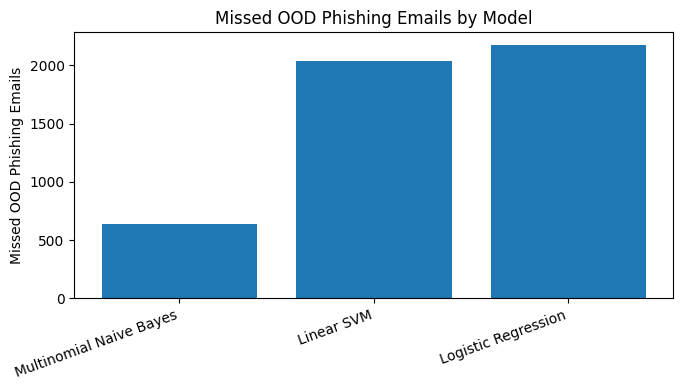

In [ ]:
# Step 14.4: Plot missed OOD phishing emails by model

ood_false_negative_plot = compact_false_negative_summary[
    compact_false_negative_summary["Evaluation Split"] == "OOD"
][[
    "Model",
    "Total Missed Phishing"
]].copy()

ood_false_negative_plot = ood_false_negative_plot.sort_values(
    by="Total Missed Phishing",
    ascending=True
).reset_index(drop=True)

plt.figure(figsize=(7, 4))

plt.bar(
    ood_false_negative_plot["Model"],
    ood_false_negative_plot["Total Missed Phishing"]
)

plt.ylabel("Missed OOD Phishing Emails")
plt.title("Missed OOD Phishing Emails by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.show()

## Observations from Security-Focused False Negative Analysis

The false negative analysis focuses on phishing emails that were not identified as phishing. This is important because missed phishing emails represent a higher security risk than many ordinary classification errors.

On the held-out test set, Logistic Regression and Linear SVM missed relatively few phishing emails, which is consistent with their high test phishing recall. Multinomial Naive Bayes missed more phishing emails on the held-out test set, reflecting its weaker conventional performance.

The OOD split shows a different pattern. Multinomial Naive Bayes missed fewer OOD phishing emails than Logistic Regression and Linear SVM, even though it performed worse under validation and held-out test conditions. The graph reinforces this security-focused difference by showing that the two stronger conventional models missed a much larger number of OOD phishing emails.

This result supports the dissertation argument that phishing detection models should be evaluated using security-relevant metrics such as phishing recall, missed phishing count and false negative rate, rather than relying on accuracy alone.

# Step 15: Save Model Artefacts and Result Tables

This section saves the trained models, TF-IDF vectoriser and key result tables.

Saving these artefacts supports reproducibility because the experiment outputs can be reviewed later without rerunning every notebook cell. The saved result tables can also be used when writing the implementation, results and evaluation chapters of the dissertation.

In [ ]:
# Step 15.1: Create output folders for results and model artefacts

results_dir = Path("/content/drive/MyDrive/MSc_Dissertation/05_Results")
artefacts_dir = Path("/content/drive/MyDrive/MSc_Dissertation/06_Model_Artefacts")

results_dir.mkdir(parents=True, exist_ok=True)
artefacts_dir.mkdir(parents=True, exist_ok=True)

print(f"Results folder: {results_dir}")
print(f"Model artefacts folder: {artefacts_dir}")

In [ ]:
# Step 15.2: Save key result tables as CSV files

tables_to_save = {
    "validation_summary.csv": validation_summary,
    "test_summary_all_models.csv": test_summary_all_models,
    "ood_summary_all_models.csv": ood_summary_all_models,
    "complete_model_comparison.csv": complete_model_comparison_sorted,
    "main_finding_summary.csv": main_finding_summary,
    "false_negative_summary.csv": false_negative_summary,
    "compact_false_negative_summary.csv": compact_false_negative_summary
}

for file_name, table in tables_to_save.items():
    output_path = results_dir / file_name
    table.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

In [ ]:
# Step 15.3: Save TF-IDF vectoriser and trained models

model_artefacts = {
    "tfidf_vectorizer.joblib": tfidf_vectorizer,
    "multinomial_naive_bayes_model.joblib": nb_model,
    "logistic_regression_model.joblib": lr_model,
    "linear_svm_model.joblib": svm_model,
    "label_mapping.joblib": label_mapping
}

for file_name, artefact in model_artefacts.items():
    output_path = artefacts_dir / file_name
    joblib.dump(artefact, output_path)
    print(f"Saved: {output_path}")

In [ ]:
# Step 15.4: Save concise experiment summary as a text file

summary_lines = [
    "AI-Based Phishing Email Detection Experiment Summary",
    "",
    f"Dataset records: {df.shape[0]}",
    f"Dataset columns: {df.shape[1]}",
    "",
    "Models evaluated:",
    "- Multinomial Naive Bayes",
    "- Logistic Regression",
    "- Linear SVM",
    "",
    "Main finding summary:",
]

for _, row in main_finding_summary.iterrows():
    summary_lines.append(
        f"- {row['Model']}: "
        f"Test phishing recall = {row['Test Phishing Recall']:.4f}, "
        f"OOD phishing recall = {row['OOD Phishing Recall']:.4f}, "
        f"missed OOD phishing emails = {int(row['Missed Phishing'])}"
    )

summary_lines.extend([
    "",
    "Interpretation:",
    "The strongest validation and held-out test models were not necessarily the most robust on the OOD phishing-only split.",
    "This supports the dissertation focus on evaluation realism, dataset structure and robustness-focused phishing detection evaluation."
])

summary_path = results_dir / "experiment_summary.txt"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

print(f"Saved: {summary_path}")

In [ ]:
# Step 15.5: Confirm saved result and artefact files

saved_results = pd.DataFrame({
    "Saved Result File": sorted([file.name for file in results_dir.iterdir() if file.is_file()])
})

saved_artefacts = pd.DataFrame({
    "Saved Artefact File": sorted([file.name for file in artefacts_dir.iterdir() if file.is_file()])
})

print("Saved result files:")
display(saved_results)

print("Saved model artefact files:")
display(saved_artefacts)

## Observations from Saving Model Artefacts and Result Tables

The trained models, TF-IDF vectoriser, label mapping and key result tables were saved to Google Drive.

The saved CSV files provide evidence for the validation, held-out test, OOD robustness and false negative analyses. These tables can be reused when writing the results and evaluation chapter.

All three trained models were saved because the dissertation does not rely on a single final model only. The comparison across models is important for showing how conventional performance and OOD robustness can lead to different interpretations.

# Step 16: Final Experiment Summary and Dissertation Findings

This final section summarises the main findings from the experiment.

The purpose is to connect the technical results back to the dissertation aim: evaluating machine-learning-based phishing email detection using conventional performance metrics and robustness-focused OOD evaluation.

In [ ]:
# Step 16.1: Display final main finding table

display(main_finding_summary.round(4))

In [ ]:
# Step 16.2: Generate final experiment interpretation

best_test_model = test_summary_all_models.sort_values(
    by=["Macro F1", "Phishing F1", "Phishing Recall", "Accuracy"],
    ascending=False
).iloc[0]["Model"]

best_ood_model = ood_summary_all_models.sort_values(
    by=["OOD Phishing Recall", "Missed Phishing"],
    ascending=[False, True]
).iloc[0]["Model"]

print("Final experiment interpretation")
print("=" * 80)
print(f"Best model under held-out test evaluation: {best_test_model}")
print(f"Best model under OOD phishing recall evaluation: {best_ood_model}")
print()
print("Main dissertation finding:")
print(
    "The strongest model under conventional validation and held-out test evaluation "
    "was not necessarily the most robust model under OOD phishing conditions."
)
print()
print("Implication:")
print(
    "Phishing detection models should be evaluated using both conventional metrics "
    "and robustness-focused measures such as OOD phishing recall, missed phishing count "
    "and phishing false negative rate."
)

In [ ]:
# Step 16.3: Create final notebook summary table

final_notebook_summary = pd.DataFrame({
    "Experiment Area": [
        "Dataset inspection",
        "Feature extraction",
        "Baseline models",
        "Validation evaluation",
        "Held-out test evaluation",
        "OOD robustness evaluation",
        "False negative analysis",
        "Saved artefacts"
    ],
    "Completed Output": [
        "Dataset shape, labels, split structure, missing values and campaign-related checks",
        "TF-IDF vectorisation using training data only",
        "Multinomial Naive Bayes, Logistic Regression and Linear SVM",
        "Comparison of conventional validation performance",
        "Comparison of held-out test performance across all models",
        "Phishing-only OOD recall and missed phishing analysis",
        "Security-focused analysis of phishing emails missed by each model",
        "Models, TF-IDF vectoriser, result tables and experiment summary saved to Google Drive"
    ]
})

display(final_notebook_summary)

## Final Experiment Summary

The experiment developed and evaluated three baseline machine-learning models for phishing email detection: Multinomial Naive Bayes, Logistic Regression and Linear SVM. All models used TF-IDF features extracted from email text.

The validation and held-out test results showed that Logistic Regression and Linear SVM achieved the strongest conventional classification performance. Linear SVM produced the strongest held-out test result overall.

However, the OOD phishing-only evaluation showed a different pattern. Multinomial Naive Bayes achieved substantially higher OOD phishing recall than Logistic Regression and Linear SVM, despite having weaker validation and held-out test performance.

This result is central to the dissertation. It shows that strong validation or held-out test performance does not necessarily prove robustness under OOD phishing conditions. The experiment therefore supports the argument that phishing email detection models should be evaluated using conventional metrics, OOD robustness testing and security-focused false negative analysis.